In [7]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

# 6.10 — Cross-model validation: GLM-HMM ↔ DDM

Do the GLM-HMM latent-state quantities recover the **published subject-wise DDM** mechanism?
In this Glass-pattern (Perugini/Basso) dataset the prior acts on the **drift** (drift_offset
shifts +0.16 unequal vs equal) and **not** the starting point (`z` ~ flat). Prediction:
the GLM-HMM **prior-state occupancy / prior-bias index** tracks the DDM **drift offset**,
but the state **starting distribution** (stationary π) does *not* track DDM `z`. That double
dissociation validates the mapping and pins the GLM-HMM prior usage to the drift mechanism.

In [8]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from scipy.optimize import linear_sum_assignment

from imports import *
from config import dir_config
from src.shared_glm_hmm.grouping import session_metadata

def sigmoid(x): return 1.0/(1.0+np.exp(-x))

In [9]:
import json

processed_dir = Path(dir_config.data.processed)
shared_dir = processed_dir / "shared_glm_hmm"
# Track the model finalized in 6.00 (selected_model.json); fall back to XY__tgt if absent.
_sel = shared_dir / "selected_model.json"
SELECTED = json.loads(_sel.read_text())["config"] if _sel.exists() else "XY__tgt"
CONFIG = SELECTED

bundle = pickle.load(open(shared_dir / CONFIG / "all_subjects_final.pkl", "rb"))
pooled = bundle["model"]["pooled"]
smodels = bundle["model"]["models"]
feats = bundle["config"]["model_features"]
K = bundle["best_k"]
data = bundle["data"]
ci, bi = feats.index("color"), feats.index("bias")
ref_w = -pooled.observations.params[:, 0, :]            # (K, M) shared basis
prior_state = int(np.argmax(ref_w[:, ci]))             # max color weight = prior-using state
state_names = {0: "Positive biased", 1: "Negative biased", 2: "Unbiased", 3: "Lapse"}

sess_md = session_metadata(pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")).set_index("session_id")
# subject-wise DDM params (already fit), per session = (subject, medication)
ddm = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60_ddm_params.csv").drop_duplicates("session_id").set_index("session_id")
print(f"CONFIG={CONFIG}  K={K}  prior_state=S{prior_state} ({state_names[prior_state]})  color wt={ref_w[prior_state, ci]:.3f}")

CONFIG=XY__tgt  K=4  prior_state=S1 (Negative biased)  color wt=0.334


## 1. Per-session GLM-HMM prior quantities + DDM prior effects

In [10]:
def align_perm(w, ref):
    cost = np.array([[np.sum((w[i]-ref[j])**2) for j in range(len(ref))] for i in range(len(w))])
    _, col = linear_sum_assignment(cost); inv = np.empty_like(col); inv[col] = np.arange(len(col)); return inv

def session_post(model, df):
    obs = df["choices"].values.astype(int).reshape(-1, 1)
    inp = df[feats].values.astype(float)
    msk = df["mask"].values.astype(bool).reshape(-1, 1)
    return model.expected_states(data=obs, input=inp, mask=msk)[0], msk[:, 0]

def stationary(T):
    vals, vecs = np.linalg.eig(T.T); i = int(np.argmin(np.abs(vals - 1)))
    p = np.real(vecs[:, i]); return p / p.sum()

wb, wc = ref_w[:, bi], ref_w[:, ci]
rows = []
for sid, df in data.items():
    post, v = session_post(pooled, df)
    occ = post[v].mean(0)
    # prior-bias index in P(right) units: prior-induced shift at zero coherence
    prior_idx = float(np.sum(occ * sigmoid(wb + wc)) - np.sum(occ * sigmoid(wb)))
    # stationary (starting) distribution from the per-session aligned transition matrix
    m = smodels[sid]; perm = align_perm(-m.observations.params[:, 0, :], ref_w)
    pi = stationary(m.transitions.transition_matrix[np.ix_(perm, perm)])
    rows.append(dict(session_id=sid, occ_prior=occ[prior_state], prior_idx=prior_idx, pi_prior=pi[prior_state]))

g = pd.DataFrame(rows).set_index("session_id").join(sess_md)
# DDM prior effects (unequal cond_1 minus equal cond_0)
g["ddm_drift_prior"] = ddm["drift_offset_prior_cond_1"] - ddm["drift_offset_prior_cond_0"]
g["ddm_z_prior"]     = ddm["z_prior_cond_1"] - ddm["z_prior_cond_0"]
g["ddm_drift_unequal"] = ddm["drift_offset_prior_cond_1"]
g["ddm_z_unequal"]     = ddm["z_prior_cond_1"]
print("merged session table:", g.shape)
g[["occ_prior", "prior_idx", "pi_prior", "ddm_drift_prior", "ddm_z_prior"]].describe().round(3)

merged session table: (100, 11)


,occ_prior,prior_idx,pi_prior,ddm_drift_prior,ddm_z_prior
count,100.000,100.000,100.000,100.000,100.000
mean,0.360,0.053,0.256,0.176,0.004
std,0.281,0.015,0.305,0.603,0.049
min,0.002,0.018,-0.000,-1.321,-0.102
25%,0.095,0.043,0.000,-0.183,-0.030
50%,0.345,0.054,0.128,0.196,-0.000
75%,0.572,0.065,0.370,0.522,0.034
max,0.966,0.078,1.000,1.740,0.146


## 2. Correlations — GLM-HMM vs DDM

Expected: GLM-HMM prior usage (occupancy, prior-bias index) correlates with DDM **drift**, not **z**; and the **starting** distribution (π) is the one that should (fail to) track `z`.

In [11]:
def corr(a, b):
    d = g[[a, b]].dropna()
    r, p = pearsonr(d[a], d[b]); rs, ps = spearmanr(d[a], d[b])
    return dict(x=a, y=b, n=len(d), pearson_r=round(r, 3), pearson_p=round(p, 4), spearman_r=round(rs, 3), spearman_p=round(ps, 4))

pairs = [("prior_idx", "ddm_drift_prior"), ("occ_prior", "ddm_drift_prior"),
         ("prior_idx", "ddm_z_prior"), ("occ_prior", "ddm_z_prior"),
         ("pi_prior", "ddm_z_prior"), ("pi_prior", "ddm_drift_prior")]
ctab = pd.DataFrame([corr(x, y) for x, y in pairs])
print("Cross-model correlations (GLM-HMM x DDM):")
ctab

Cross-model correlations (GLM-HMM x DDM):


,x,y,n,pearson_r,pearson_p,spearman_r,spearman_p
0,prior_idx,ddm_drift_prior,100,0.219,0.0283,0.300,0.0024
1,occ_prior,ddm_drift_prior,100,0.128,0.2056,0.169,0.0924
2,prior_idx,ddm_z_prior,100,-0.078,0.4407,-0.056,0.5825
3,occ_prior,ddm_z_prior,100,0.019,0.8486,0.038,0.7042
4,pi_prior,ddm_z_prior,100,-0.038,0.7064,-0.059,0.5607
5,pi_prior,ddm_drift_prior,100,0.060,0.5534,-0.012,0.9067


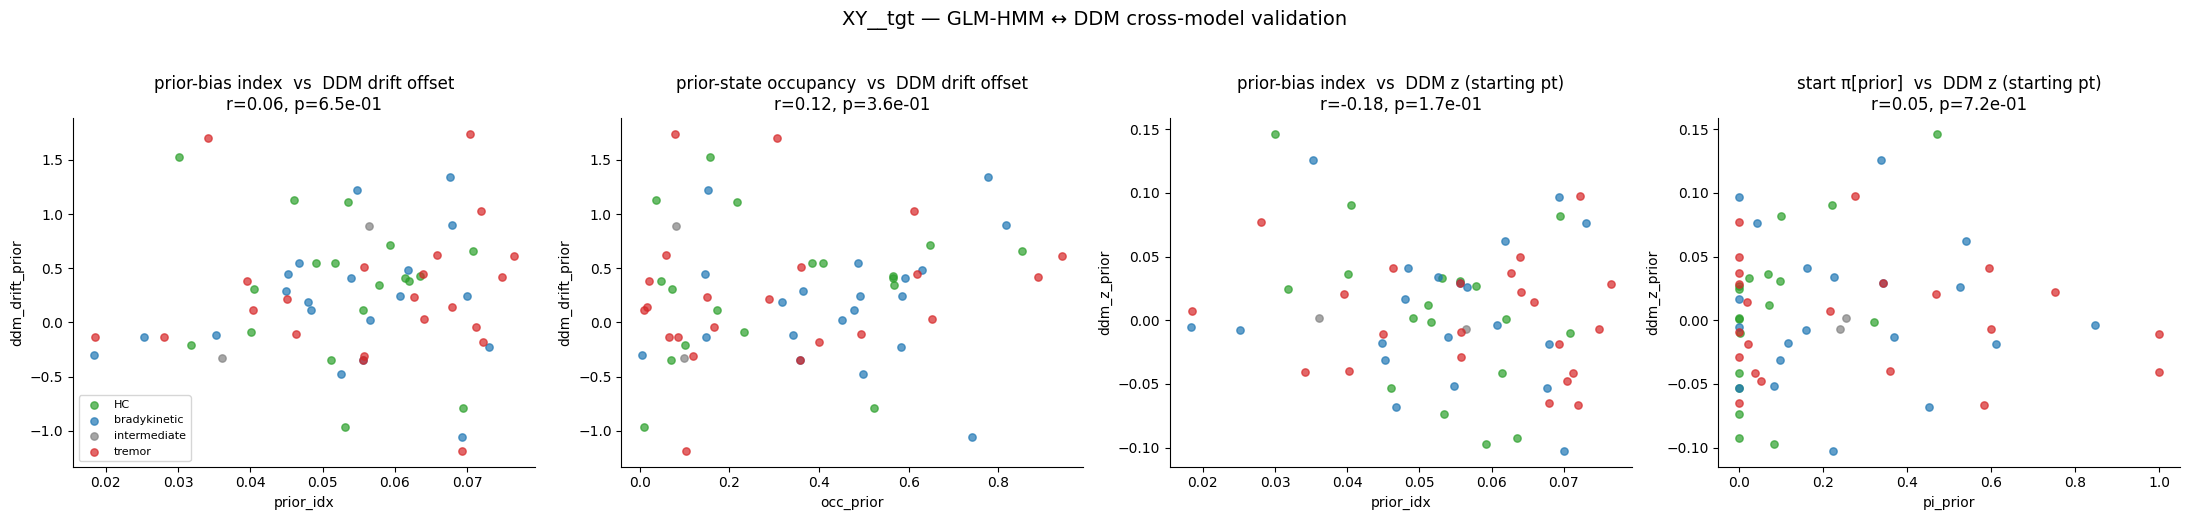

In [12]:
cmap = {"HC":"tab:green","tremor":"tab:red","bradykinetic":"tab:blue","intermediate":"gray"}
panels = [("prior_idx","ddm_drift_prior","prior-bias index  vs  DDM drift offset"),
          ("occ_prior","ddm_drift_prior","prior-state occupancy  vs  DDM drift offset"),
          ("prior_idx","ddm_z_prior","prior-bias index  vs  DDM z (starting pt)"),
          ("pi_prior","ddm_z_prior","start π[prior]  vs  DDM z (starting pt)")]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (x, y, title) in zip(axes, panels):
    d = g[[x, y, "subtype"]].dropna()
    for sub, dd in d.groupby("subtype", observed=True):
        ax.scatter(dd[x], dd[y], s=28, alpha=0.7, color=cmap.get(sub, "gray"), label=sub)
    r, p = pearsonr(d[x], d[y])
    ax.set(xlabel=x, ylabel=y, title=f"{title}\nr={r:.2f}, p={p:.1e}")
    ax.spines[["top","right"]].set_visible(False)
axes[0].legend(fontsize=8)
fig.suptitle(f"{CONFIG} — GLM-HMM ↔ DDM cross-model validation", fontsize=14, y=1.03)
plt.tight_layout(); plt.show()

## 3. Read-out

If `prior_idx`/`occ_prior` correlate with **DDM drift** but not **z**, and π[prior] does not
track `z`, then the GLM-HMM prior-using state is the **drift-mechanism analog** — a clean
translation of the Perugini DDM result into latent-state terms, and a cross-model validation
that neither model alone provides.